In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import lil_matrix
from itertools import product

from pathlib import Path
file_path = Path("../data/connected_projection_graph.graphml")

In [2]:
G = nx.read_graphml(file_path)

In [3]:
# Inspect node attributes
sample_node = list(G.nodes(data=True))[:5]
sample_node

[('1', {'node_ID': 0, 'node_type': 'person', 'node_value': 'TA'}),
 ('2', {'node_ID': 80, 'node_type': 'person', 'node_value': 'Student'}),
 ('4', {'node_ID': 162, 'node_type': 'person', 'node_value': 'Student'}),
 ('5', {'node_ID': 7, 'node_type': 'person', 'node_value': 'Student'}),
 ('14', {'node_ID': 170, 'node_type': 'person', 'node_value': 'Student'})]

## Node metrics

In [4]:
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

ec_df = pd.DataFrame(
    sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True),
    columns=["node", "eigenvector_centrality"]
)
ec_df.head(20)

,node,eigenvector_centrality
0,1,0.107131
1,37,0.106739
2,87,0.106687
3,113,0.106664
4,222,0.106164
5,41,0.106141
6,282,0.106043
7,310,0.105780
8,208,0.105622
9,158,0.105305


In [5]:
pagerank = nx.pagerank(G)

pr_df = pd.DataFrame(
    sorted(pagerank.items(), key=lambda x: x[1], reverse=True),
    columns=["node", "pagerank"]
)
pr_df.head(20)

,node,pagerank
0,310,0.009616
1,222,0.009375
2,1,0.009374
3,87,0.009311
4,269,0.009143
5,37,0.009140
6,41,0.009091
7,113,0.009027
8,282,0.008913
9,208,0.008893


In [6]:
def plot_graph_by_metric(G, metric_dict, title="Graph Colored by Metric", cmap="coolwarm", node_size=50, show_labels=False, font_size=6):
    """Display graph with nodes colored by a metric value.
    
    Args:
        G: A NetworkX graph.
        metric_dict: Dict mapping node -> metric value.
        title: Plot title.
        cmap: Matplotlib colormap name.
        node_size: Size of drawn nodes.
        show_labels: Whether to draw node labels.
        font_size: Font size for node labels.
    """
    nodes = list(G.nodes())
    values = np.array([metric_dict.get(n, 0) for n in nodes])

    fig, ax = plt.subplots(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=42)

    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=values.min(), vmax=values.max()),
    )
    node_colors = sm.to_rgba(values)

    nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=node_colors,
                           node_size=node_size, ax=ax)

    if show_labels:
        nx.draw_networkx_labels(G, pos, font_size=font_size, ax=ax)

    sm.set_array([])
    plt.colorbar(sm, ax=ax)
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

In [7]:
degree_dict = dict(G.degree())

deg_df = pd.DataFrame(
    sorted(degree_dict.items(), key=lambda x: x[1], reverse=True),
    columns=["node", "degree"]
)
deg_df.head(20)

,node,degree
0,1,169
1,37,166
2,87,166
3,222,166
4,41,165
5,113,165
6,310,164
7,282,163
8,208,162
9,96,161


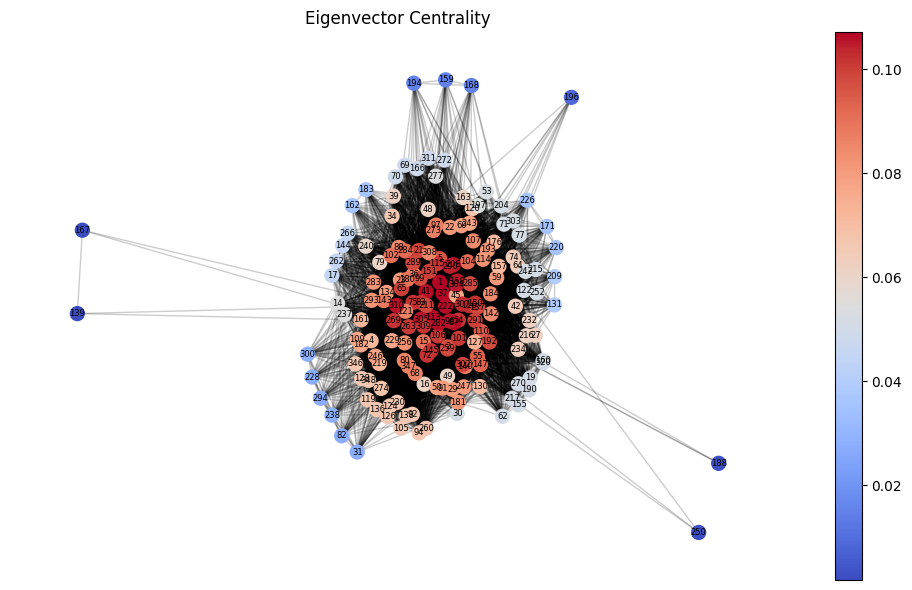

In [8]:
plot_graph_by_metric(G, eigenvector_centrality, title="Eigenvector Centrality", node_size=100, show_labels=True)

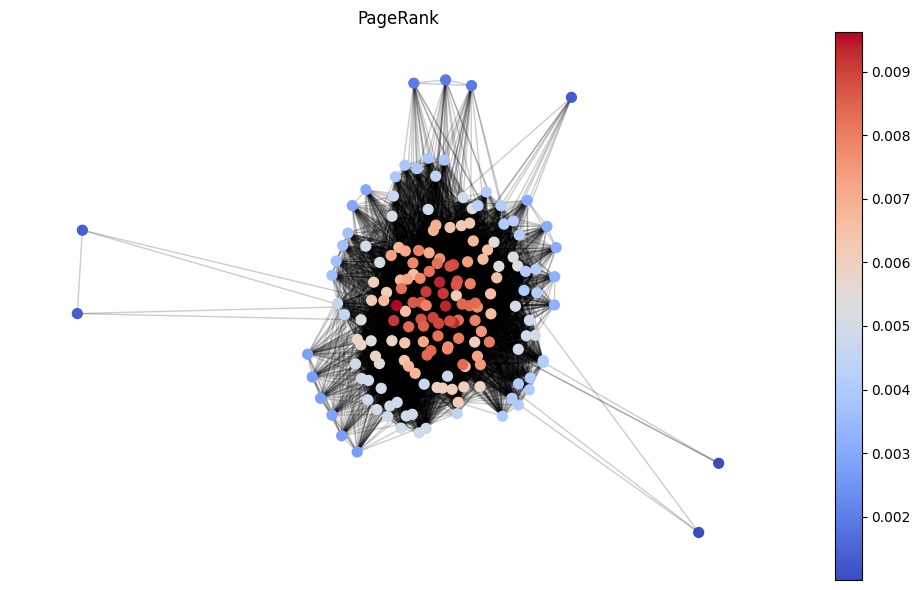

In [9]:
plot_graph_by_metric(G, pagerank, title="PageRank")

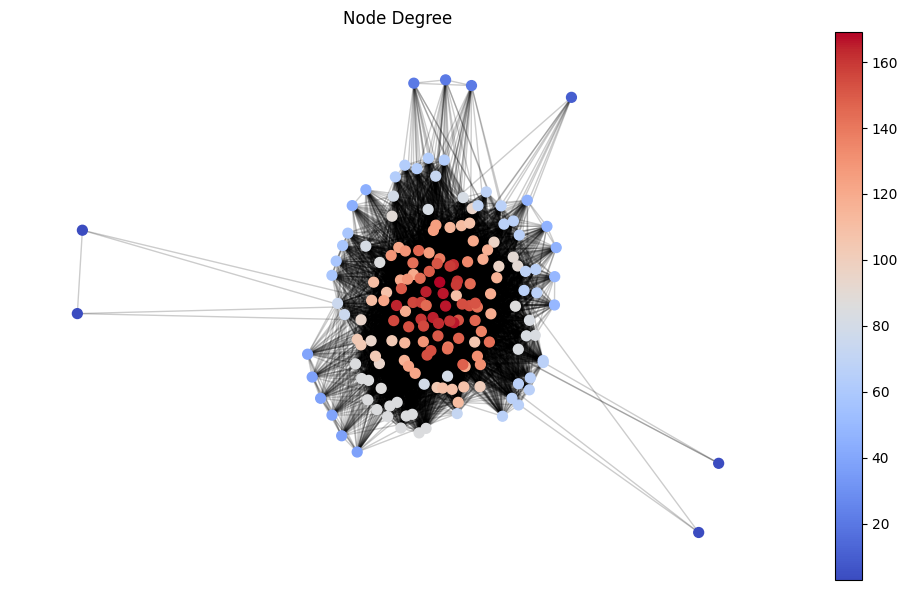

In [10]:
plot_graph_by_metric(G, degree_dict, title="Node Degree")

In [11]:
role_dict = {n: d["node_value"] for n, d in G.nodes(data=True)}
role_df = pd.DataFrame(role_dict.items(), columns=["node", "role"])

metrics_df = ec_df.merge(pr_df, on="node").merge(deg_df, on="node").merge(role_df, on="node")
metrics_df.head(20)

,node,eigenvector_centrality,pagerank,degree,role
0,1,0.107131,0.009374,169,TA
1,37,0.106739,0.009140,166,Student
2,87,0.106687,0.009311,166,Student
3,113,0.106664,0.009027,165,Student
4,222,0.106164,0.009375,166,Student
5,41,0.106141,0.009091,165,TA
6,282,0.106043,0.008913,163,Student
7,310,0.105780,0.009616,164,Student
8,208,0.105622,0.008893,162,Student
9,158,0.105305,0.008772,160,Student


In [12]:
metrics_df[metrics_df['role'] == 'TA']

,node,eigenvector_centrality,pagerank,degree,role
0,1,0.107131,0.009374,169,TA
5,41,0.106141,0.009091,165,TA
15,83,0.102391,0.008683,157,TA
19,75,0.102097,0.008627,156,TA
49,180,0.090078,0.007197,129,TA
72,23,0.080783,0.006854,120,TA
125,277,0.053980,0.004446,73,TA
166,159,0.015123,0.001930,21,TA
167,168,0.015123,0.001930,21,TA
168,194,0.015123,0.001930,21,TA


In [14]:
metrics_df['ec_quantile'] = pd.qcut(metrics_df['eigenvector_centrality'], q=4, labels=[1, 2, 3, 4])
metrics_df['pr_quantile'] = pd.qcut(metrics_df['pagerank'], q=4, labels=[1, 2, 3, 4])
metrics_df['degree_quantile'] = pd.qcut(metrics_df['degree'], q=4, labels=[1, 2, 3, 4])
metrics_df

,node,eigenvector_centrality,pagerank,degree,role,ec_quantile,pr_quantile,degree_quantile
0,1,0.107131,0.009374,169,TA,4,4,4
1,37,0.106739,0.009140,166,Student,4,4,4
2,87,0.106687,0.009311,166,Student,4,4,4
3,113,0.106664,0.009027,165,Student,4,4,4
4,222,0.106164,0.009375,166,Student,4,4,4
...,...,...,...,...,...,...,...,...
169,196,0.008698,0.001332,10,Student,1,1,1
170,188,0.002709,0.001006,3,Student,1,1,1
171,250,0.002353,0.001008,3,Student,1,1,1
172,139,0.001827,0.001343,3,Student,1,1,1


## Communities

In [4]:
import sys
sys.path.insert(0, str(Path("..").resolve()))

from src.partitioning_utils import Newman_hill_climbing
from src.partitioning_utils import modularity_spectral_split
from src.partitioning_utils import normalized_laplacian_graph_cut

from src.drawing_utils import show_kCores

In [61]:
def plot_graph_by_partition(G, partition, title="Graph Colored by Community", cmap="tab10", node_size=50, show_labels=False, font_size=6):
    """Display graph with nodes colored by partition/community group.
    
    Args:
        G: A NetworkX graph.
        partition: List of sets, where each set contains the nodes in a community.
        title: Plot title.
        cmap: Matplotlib colormap name.
        node_size: Size of drawn nodes.
        show_labels: Whether to draw node labels.
        font_size: Font size for node labels.
    """
    node_to_community = {}
    for i, community in enumerate(partition):
        for node in community:
            node_to_community[node] = i

    nodes = list(G.nodes())
    community_ids = [node_to_community.get(n, -1) for n in nodes]
    num_communities = len(partition)

    colormap = plt.cm.get_cmap(cmap, num_communities)
    node_colors = [colormap(c) for c in community_ids]

    fig, ax = plt.subplots(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=node_colors,
                           node_size=node_size, ax=ax)

    if show_labels:
        nx.draw_networkx_labels(G, pos, font_size=font_size, ax=ax)

    # Add legend for communities
    handles = [plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=colormap(i), markersize=8,
               label=f"Community {i}") for i in range(num_communities)]
    ax.legend(handles=handles, loc="best")

    modularity = nx.community.modularity(G, partition)
    ax.set_title(f"{title}\nModularity: {modularity:.4f}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

In [68]:
from typing import Hashable

seed = 42
resolution = 0.95
louvain_partition: list[set[Hashable]] = nx.community.louvain_communities(G,
                                                                  seed=seed,
                                                                  resolution=resolution)

/var/folders/9q/cx1cf_5s6js6_b_9t6f0jdgh0000gn/T/ipykernel_24179/2644399506.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap(cmap, num_communities)


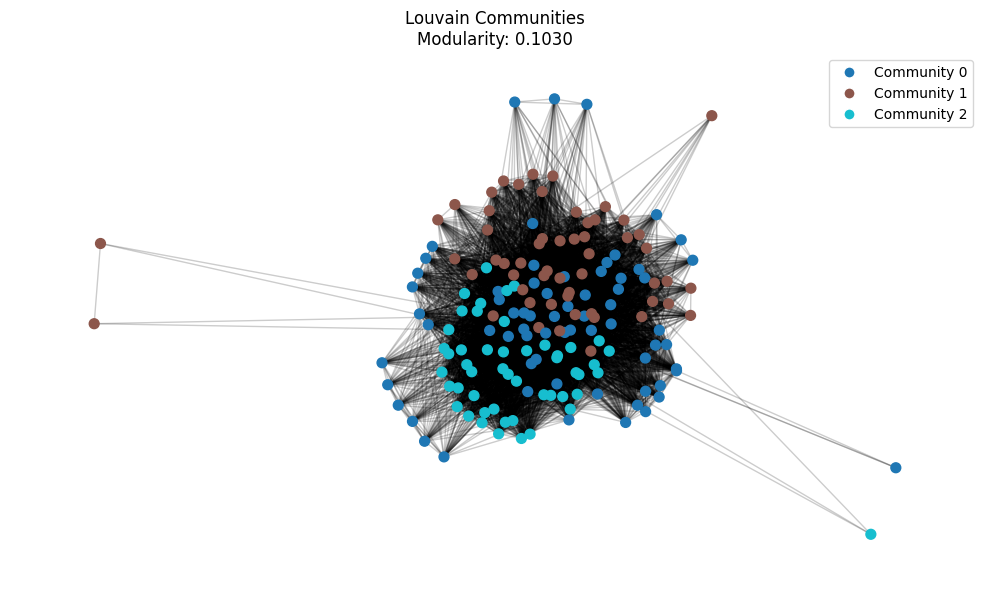

In [69]:
plot_graph_by_partition(G, louvain_partition, title="Louvain Communities")

In [70]:
newman_partition: list[set[Hashable]] = Newman_hill_climbing(G)
while len(newman_partition) < len(louvain_partition):
    newman_partition = sub_partition(G, newman_partition, partition_method=Newman_hill_climbing) 

/var/folders/9q/cx1cf_5s6js6_b_9t6f0jdgh0000gn/T/ipykernel_24179/2644399506.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap(cmap, num_communities)


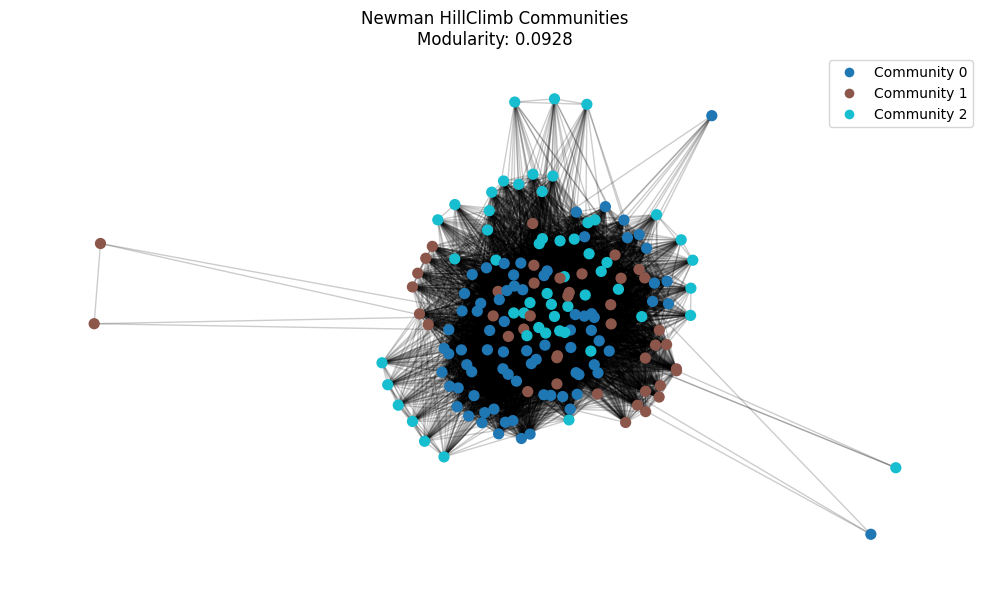

In [71]:
plot_graph_by_partition(G, newman_partition, title="Newman HillClimb Communities")

In [73]:
spectral_partition: list[set[Hashable]] = modularity_spectral_split(G)
while len(spectral_partition) < len(louvain_partition):
    spectral_partition = sub_partition(G, spectral_partition, partition_method=modularity_spectral_split) 

/var/folders/9q/cx1cf_5s6js6_b_9t6f0jdgh0000gn/T/ipykernel_24179/2644399506.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap(cmap, num_communities)


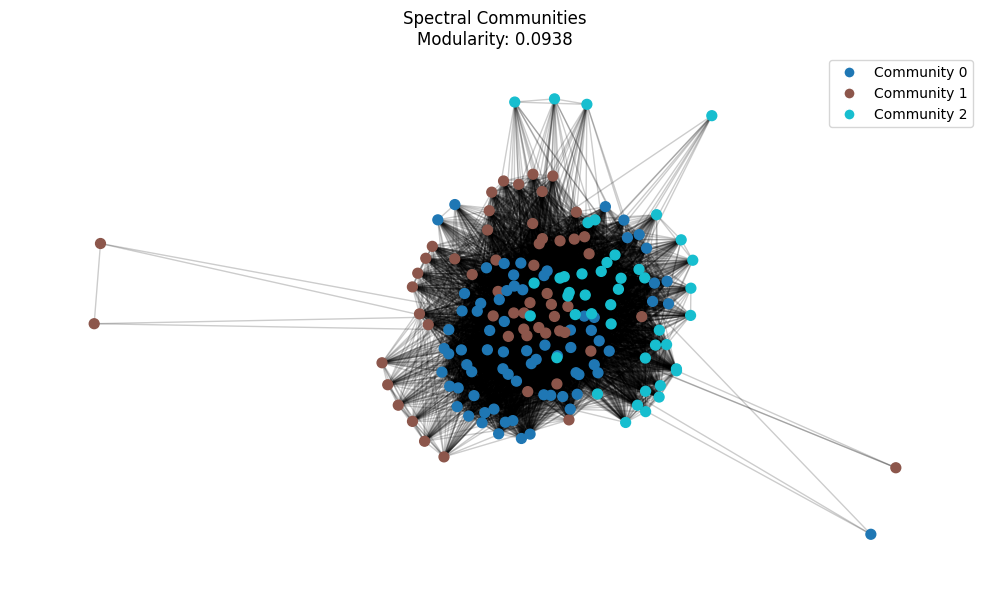

In [74]:
plot_graph_by_partition(G, spectral_partition, title="Spectral Communities")

In [82]:
laplacian_norm_cut_partition = normalized_laplacian_graph_cut(G)
while len(laplacian_norm_cut_partition) < 3:
    laplacian_norm_cut_partition = sub_partition(G, laplacian_norm_cut_partition, partition_method=normalized_laplacian_graph_cut)

/var/folders/9q/cx1cf_5s6js6_b_9t6f0jdgh0000gn/T/ipykernel_24179/2644399506.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap(cmap, num_communities)


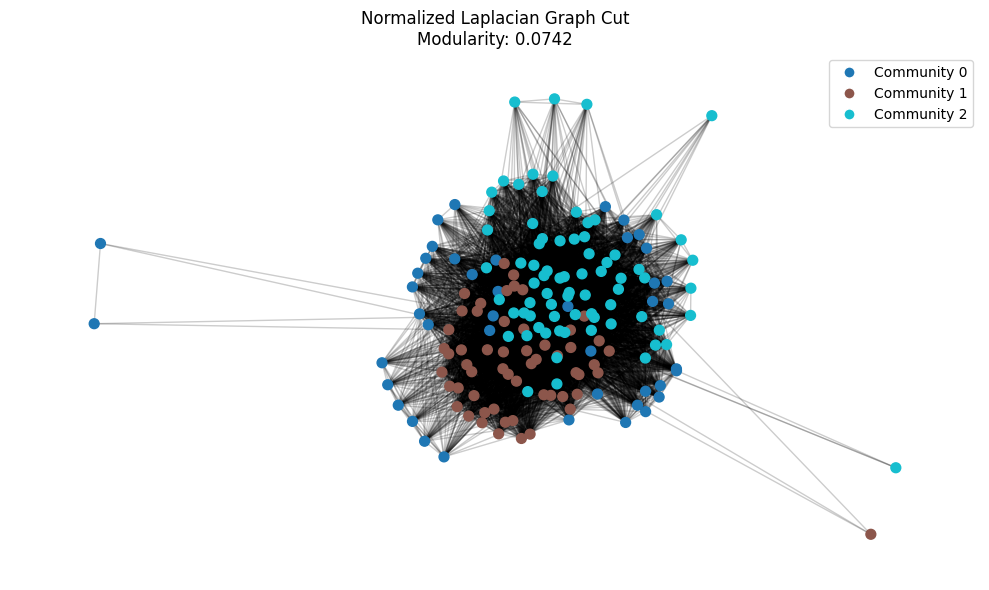

In [83]:
plot_graph_by_partition(G, laplacian_norm_cut_partition, "Normalized Laplacian Graph Cut")

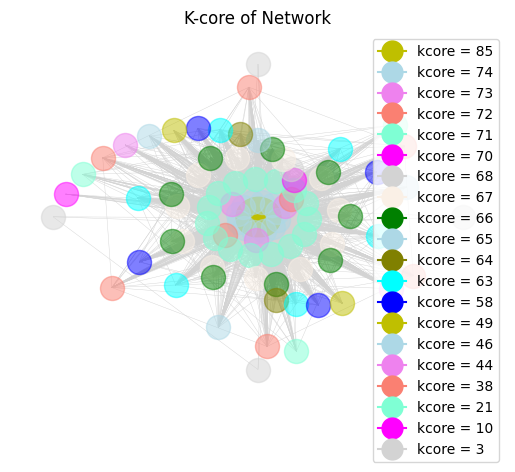

In [5]:
from src.drawing_utils import show_kCores
show_kCores(G)

## NOTES

This graph appears to have more of a core-perepherie structure then structured communities. The community detection algorithms didn't seem to perform that well, with the highest modularity being from the Louvain clustering with 3 communities (0.1).  

From looking at the graph visulization with the spring layout, there appears to be maybe 1 or 2 large communities and then several outliers.  

Some potential influential nodes could be found in the core of the graph, like node 1 for example, which is the most central node by the three metrics used. Most TA nodes are in the upper 2 quantiles (6/10), I would be interested to see how modeling the complex contagion with only TAs works.  

Top 5 TAs (eigenvector_centrality): [ 1, 41, 83, 75, 180 ]  
Top 10 Students (eigenvector_centrality): [ 37, 87, 113, 222, 282, 310, 208, 158, 304 ]

